In [2]:
import pandas as pd
import networkx as nx
import numpy as np

In [3]:
def build_pmfg_from_graph(G):
    # 1. Criar a lista Sord a partir das arestas do grafo G (com pesos)
    # Assumindo que 'weight' representa a similaridade
    edges = [(u, v, d['weight']) for u, v, d in G.edges(data=True)]
    
    # Ordena decrescentemente pelo peso (similaridade) [1]
    edges.sort(key=lambda x: x[2], reverse=True)
    
    n = G.number_of_nodes()
    pmfg = nx.Graph()
    pmfg.add_nodes_from(G.nodes())
    
    max_edges = 3 * (n - 2) # Limite para gênero g=0 [6]
    current_edge_count = 0
    
    for u, v, weight in edges:
        if current_edge_count >= max_edges:
            break
            
        pmfg.add_edge(u, v, weight=weight)
        is_planar, _ = nx.check_planarity(pmfg)
        
        if is_planar:
            current_edge_count += 1
        else:
            pmfg.remove_edge(u, v)
            
    return pmfg

In [4]:
# lendo o grafo original
graph_corr = nx.read_graphml('new_correlacao_b3.graphml')

# criando o pmfg
pmfg_graph = build_pmfg_from_graph(graph_corr)

In [5]:
# verificando se o grafo do pmfg é planar e confirmando 
# que a maior clique é de tamanho 4

from networkx.algorithms.clique import find_cliques

cliques = list(find_cliques(pmfg_graph))

maior_clique = max(cliques, key=len) # clique de maior tamanho
print(f"Tamanho da maior clique: {len(maior_clique)}")
print(f"Ativos: {maior_clique}")

Tamanho da maior clique: 4
Ativos: ['BTLG11', 'PMLL11', 'XPML11', 'VISC11']


In [6]:
from collections import Counter

def juntar_cliques(cliques_3, cliques_4):
    seen = set()
    for c in cliques_3 + cliques_4:
        if tuple(c) not in seen:
            seen.add(tuple(c))
    return list(seen)

def identificar_vertices_significativos(G_pmfg):
    """
    Identifica vértices significativos com base na participação em cliques,
    conforme a lógica apresentada no paper de Tumminello recomendado.
    """
    # encontrar todos os cliques
    todos_cliques = list(nx.find_cliques(G_pmfg))
    
    # filtrar apenas cliques de 3 e 4 elementos (base do PMFG e como esta no paper)
    cliques_4 = [c for c in todos_cliques if len(c) == 4]
    cliques_3 = [c for c in todos_cliques if len(c) == 3]
    
    print(f"Total de 3-cliques: {len(cliques_3)}") # qtd de cliques de tamanho 3
    print(f"Total de 4-cliques: {len(cliques_4)}") # qtd de cliques de tamanho 4

    # juntar os cliques de tamanho 3 e 4, eliminando os duplicados
    cliques = juntar_cliques(cliques_3, cliques_4)
    
    # contar em quantos cliques cada nó participa
    # vértices significativos participam de muitos cliques
    frequencia_nos = Counter()
    for clique in cliques: # Foco nos [3, 4]-cliques por serem mais informativos 
        frequencia_nos.update(clique)
    
    # ordenar vértices pela importância (frequência de participação)
    vertices_mais_importantes = frequencia_nos.most_common()
    
    return vertices_mais_importantes, cliques

ranking, lista_cliques = identificar_vertices_significativos(pmfg_graph)

Total de 3-cliques: 86
Total de 4-cliques: 141


In [7]:
# quantidade de ativos dentro das cliques que é uma junção das cliques de tamanho 3 e 4
print(f"qtd de ativos: {len(lista_cliques)}")

# validando se há ativos duplicados
cont = Counter(lista_cliques)
duplicados = [item for item, qtd in cont.items() if qtd > 1]
print(f"ativos duplicados: {duplicados}")

qtd de ativos: 227
ativos duplicados: []


In [8]:
# fazendo o stock picking a partir de ativos que aparecem acima de 5, 7 e 10
# cliques, como ativos de maiores relevancias.
ativos_selecionados_5 = [(stock, freq) for stock, freq in ranking if freq >=5]
ativos_selecionados_7 = [(stock, freq) for stock, freq in ranking if freq >=7]
ativos_selecionados_10 = [(stock, freq) for stock, freq in ranking if freq >=10]
ativos_selecionados_15 = [(stock, freq) for stock, freq in ranking if freq >=15]

In [9]:
# criando dataframe
stock_picking_5  = pd.DataFrame(ativos_selecionados_5, columns=['stock', 'freq'])
stock_picking_7  = pd.DataFrame(ativos_selecionados_7, columns=['stock', 'freq'])
stock_picking_10 = pd.DataFrame(ativos_selecionados_10, columns=['stock', 'freq'])
stock_picking_15 = pd.DataFrame(ativos_selecionados_15, columns=['stock', 'freq'])

In [10]:
k = pd.read_parquet('data/processed/data_assets.parquet')
# Calcular retornos log (mais estável que preço bruto)
returns = np.log(k['Close'] / k['Close'].shift(1))

# carregando a matriz de correlação
cmat = pd.read_parquet('data/processed/corr_matrix.parquet')

# filtrando os retornos dos ativos selecionados a partir do processo do PFMG
# usando os ativos selecionados a partir do processo do PFMG nos vertices de maior
# influencia que aparecem acima de 5, 7, 10 e 15 ocorrencias em cliques de tamanho 3 e 4 para 
# filtrar a matriz de retornos e correlacao, essa matriz de retornos e correlacao
# sera usada para definir o peso dos ativos selecionados, como no paper o autor 
# não especifica uma forma, aplicaremos conceitos classicos da literatura de 
# alocação de portofolio
ret_stockpick_5 = returns.loc[:, stock_picking_5['stock'].tolist()]
ret_stockpick_7 = returns.loc[:, stock_picking_7['stock'].tolist()]
ret_stockpick_10 = returns.loc[:, stock_picking_10['stock'].tolist()]
ret_stockpick_15 = returns.loc[:, stock_picking_15['stock'].tolist()]

cor_stockpick_5 = cmat.loc[:, stock_picking_5['stock'].tolist()]
cor_stockpick_7 = cmat.loc[:, stock_picking_7['stock'].tolist()]
cor_stockpick_10 = cmat.loc[:, stock_picking_10['stock'].tolist()]
cor_stockpick_15 = cmat.loc[:, stock_picking_15['stock'].tolist()]

ativos_5 = stock_picking_5["stock"].dropna().astype(str).unique()
ativos_7 = stock_picking_7["stock"].dropna().astype(str).unique()
ativos_10 = stock_picking_10["stock"].dropna().astype(str).unique()
ativos_15 = stock_picking_15["stock"].dropna().astype(str).unique()

returns_filtrado_5 = returns.loc[:, returns.columns.intersection(ativos_5)]
returns_filtrado_7 = returns.loc[:, returns.columns.intersection(ativos_7)]
returns_filtrado_10 = returns.loc[:, returns.columns.intersection(ativos_10)]
returns_filtrado_15 = returns.loc[:, returns.columns.intersection(ativos_15)]

C:\Users\kimbo\AppData\Roaming\Python\Python313\site-packages\pandas\core\internals\blocks.py:395: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


##### Backtesting portfolio PMFG 5, 7, 10, 15

In [11]:
"""
Definição do tamanho da janela in-sample do backtest
"""
InS = 120  # tamanho da janela (dias)

In [12]:
from allocation import risk_parity

def backtesting(returns_filtrado, estrategia, in_sample=InS):
    """
    Usa T dias in-sample para calcular os pesos e o dia T+1 para o retorno out-of-sample.
    Retorna uma Series independente (sem alterar um DataFrame global compartilhado).
    """
    aux = returns_filtrado.columns.tolist()
    oos = returns_filtrado.shape[0] - in_sample

    retornos = []
    pesos = []

    for i in range(oos):
        retu_ins = returns_filtrado.iloc[i:(in_sample + i)][aux]
        r_oos = returns_filtrado.iloc[in_sample + i][aux].to_numpy()

        w_pmfg = risk_parity.risk_parity_portfolio(retu_ins.cov().to_numpy())
        retornos.append(w_pmfg @ r_oos)
        pesos.append(pd.Series(w_pmfg, index=aux))

    serie = pd.Series(
        retornos,
        index=returns_filtrado.index[in_sample:in_sample + oos],
        name=estrategia,
        dtype=float,
    )
    pesos_df = pd.DataFrame(pesos, index=serie.index)

    return serie, pesos_df

estrategias = [
    (returns_filtrado_5, 'PMFG_5'),
    (returns_filtrado_7, 'PMFG_7'),
    (returns_filtrado_10, 'PMFG_10'),
    (returns_filtrado_15, 'PMFG_15'),
]

resultados = {}
pesos_por_estrategia = {}

for returns_df, nome in estrategias:
    serie, pesos = backtesting(returns_df, nome)
    resultados[nome] = serie
    pesos_por_estrategia[nome] = pesos
    print(f"{nome}: {len(serie)} dias OoS | {returns_df.shape[1]} ativos")

# alinha todas as estratégias pelo índice de datas (interseção)
Rport = pd.concat(resultados.values(), axis=1)


PMFG_5: 2609 dias OoS | 28 ativos
PMFG_7: 2609 dias OoS | 21 ativos
PMFG_10: 2609 dias OoS | 11 ativos
PMFG_15: 2609 dias OoS | 6 ativos


In [13]:
Rport

,PMFG_5,PMFG_7,PMFG_10,PMFG_15
Date,,,,
2015-06-29,NaN,NaN,NaN,NaN
2015-06-30,NaN,NaN,NaN,NaN
2015-07-01,NaN,NaN,NaN,NaN
2015-07-02,NaN,NaN,NaN,NaN
2015-07-03,NaN,NaN,NaN,NaN
...,...,...,...,...
2025-12-22,0.001572,0.002551,-0.002360,-0.007800
2025-12-23,0.008316,0.007812,0.013189,0.016230
2025-12-26,0.005077,0.005904,0.005362,0.005061


In [14]:
# setando uma quantidade inicial de capital para invstimento
CAPITAL_INICIAL = 100_000

# transformando os retornos logaritmicos em retornos simples para calculo do retorno cumulativo
portfolio_returns = np.exp(Rport) - 1
# calculo do retorno cumulativo levando em consideração o capital inicial
cumulative_returns = (1 + portfolio_returns).cumprod() * CAPITAL_INICIAL

In [15]:
# calcaulando o drawdown das estrategias
max_cumulative = cumulative_returns.cummax()
drawdown = ((cumulative_returns - max_cumulative) / max_cumulative)

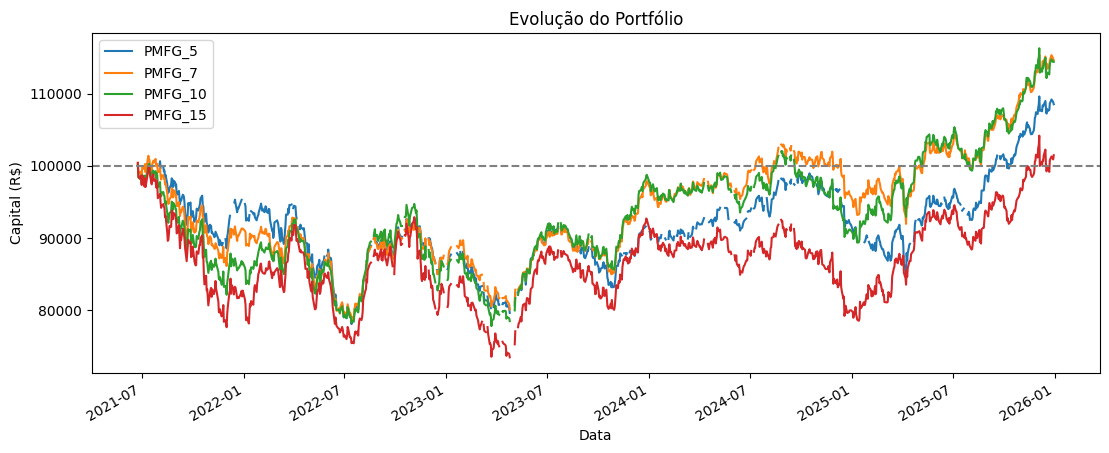

In [ ]:
import matplotlib.pyplot as plt

# plotando a evolução do portfolio no tempo
(cumulative_returns ).plot(figsize=(13, 5))

plt.axhline(y=CAPITAL_INICIAL, color='gray', linestyle='--', linewidth=1.5)
plt.title('Evolução do Portfólio')
plt.xlabel("Data")
plt.ylabel("Capital (R$)") 
plt.show()

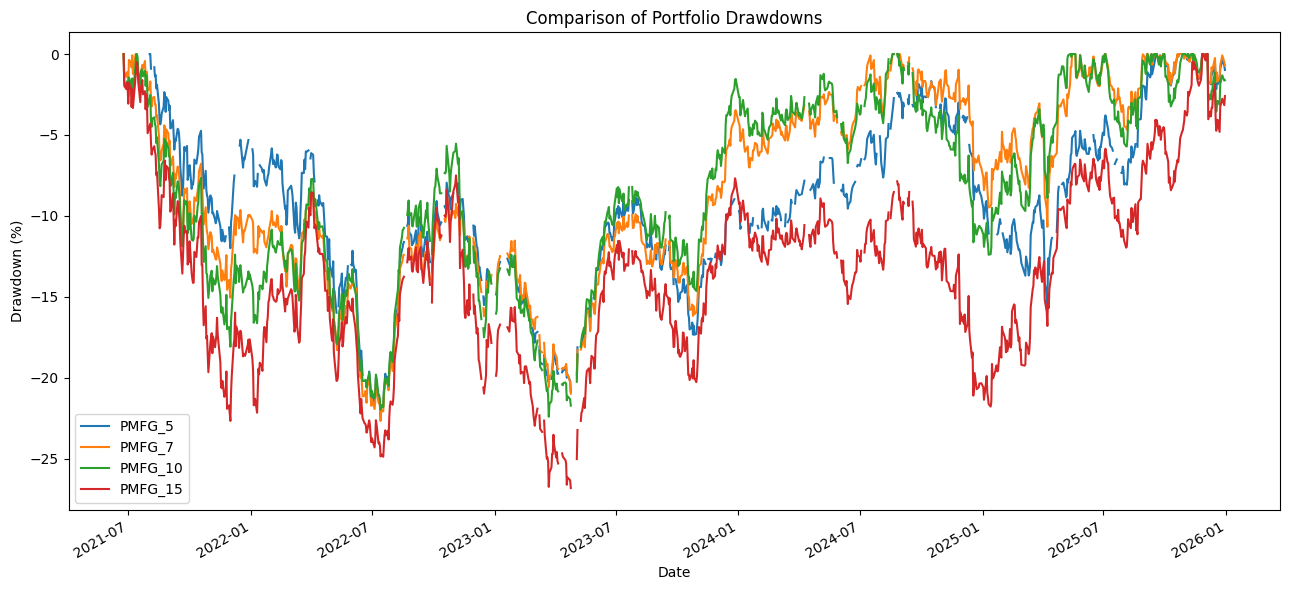

In [17]:
(drawdown * 100).plot(figsize=(13, 6))

plt.title('Comparison of Portfolio Drawdowns')
plt.xlabel('Date')
plt.ylabel('Drawdown (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
#returns_filtrado_7.to_parquet('data/processed/returns_pmfg_7.parquet')